<a href="https://colab.research.google.com/github/Asmit-06/my-repo/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Asmit-06/my-repo/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

## Ranked Actions

The ranked queue prioritizes content based on historical search performance and content freshness. Higher-ranked pages are considered stronger candidates for review because they combine older content with meaningful search visibility.

| Priority | Action | Reason Code |
|----------|---------|-------------|
| High | Refresh Immediately | STALE_HIGH_TRAFFIC |
| Medium | Review Content | STALE_LOW_TRAFFIC |
| Low | Monitor Performance | HIGH_IMPRESSIONS |
| Lowest | No Action | LOW_PRIORITY |

### Reason Codes

- **STALE_HIGH_TRAFFIC** – The content has not been updated recently and continues to receive strong search impressions.
- **STALE_LOW_TRAFFIC** – The content is old but currently has lower search visibility.
- **HIGH_IMPRESSIONS** – The page receives substantial traffic but is relatively recent.
- **LOW_PRIORITY** – The page does not currently meet the refresh criteria.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

## Intended Use

This playbook is designed to support content teams in identifying pages that may benefit from a content refresh. It provides a ranked list of recommendations based on historical search signals and should be used as a decision-support tool.

## Limitations

- Recommendations are based only on the available dataset.
- The model does not evaluate content quality or accuracy.
- Business priorities and seasonal trends are not considered.
- Results are observational and should not be interpreted as proof that refreshing content will improve performance.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

## Human Review

Before taking action, a reviewer should verify:

- The content is factually outdated.
- Search intent has changed.
- The page still supports business goals.
- There are no recent manual updates missing from the dataset.
- The recommendation aligns with editorial priorities.

## No-Go List

The following decisions should never be fully automated:

- Publishing updated content.
- Deleting or redirecting pages.
- Major SEO strategy changes.
- Business-critical content decisions.
- Final editorial approval.

These actions require human judgment.

In [11]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

## Monitoring and Retraining

The model should be reviewed or retrained when:

- New search performance data becomes available.
- Search trends change significantly.
- Recommendation quality decreases during manual review.
- Content update policies change.
- New features become available for modeling.

Regular monitoring helps maintain reliable decision-support recommendations.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

## Exports

The notebook exports the ranked action queue to the `work/outputs/` directory.

The exported files will be reused in the final research paper for presenting recommendations and supporting visualizations.

Generated outputs include:

- Ranked action queue (CSV)
- Evaluation metrics (JSON)
- Any charts or figures saved for the paper

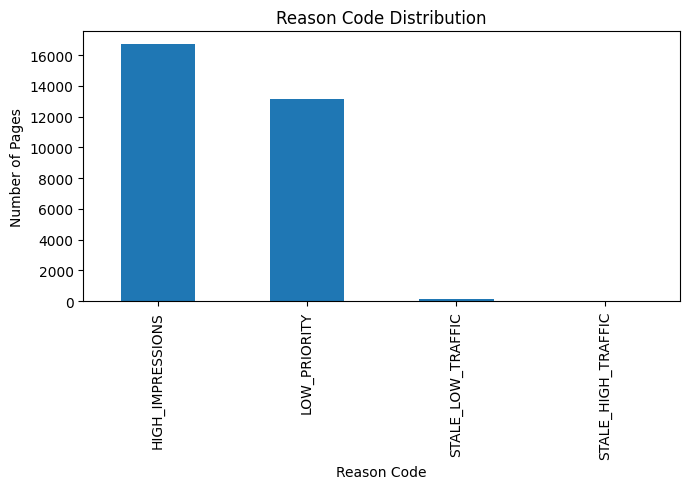

✅ Files created successfully!

CSV:
/content/my-repo/work/outputs/baseline_action_score.csv

Figure:
/content/my-repo/work/figures/reason_code_distribution.png

Files inside work/outputs:
['baseline_action_score.csv']

Files inside work/figures:
['reason_code_distribution.png']

Top 10 Recommended Pages


,content_id,baseline_score,reason_code,action,impressions_90d,days_since_last_update
16751,content_cf56e2e2e282,3,STALE_HIGH_TRAFFIC,Refresh Immediately,61678,194
16514,content_7368877ea310,3,STALE_HIGH_TRAFFIC,Refresh Immediately,59472,194
7021,content_1bfaa38ff26c,3,STALE_HIGH_TRAFFIC,Refresh Immediately,25715,194
21268,content_0a91db491d14,3,STALE_HIGH_TRAFFIC,Refresh Immediately,13299,193
11489,content_5feee3994adb,3,STALE_HIGH_TRAFFIC,Refresh Immediately,7812,194
12045,content_c2d929d83eaa,3,STALE_HIGH_TRAFFIC,Refresh Immediately,7558,193
698,content_b16bd7307b39,3,STALE_HIGH_TRAFFIC,Refresh Immediately,4590,194
5327,content_fe16a55cd13d,3,STALE_HIGH_TRAFFIC,Refresh Immediately,4556,194
26810,content_ecb6215e79fd,3,STALE_HIGH_TRAFFIC,Refresh Immediately,4429,194
20837,content_928af3e22c80,3,STALE_HIGH_TRAFFIC,Refresh Immediately,1697,193


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import pandas as pd
import matplotlib.pyplot as plt
import os


df = pd.read_csv("data/raw/content_refresh_anonymized.csv")


df["baseline_score"] = (
    (df["days_since_last_update"] >= 180).astype(int) * 2 +
    (df["impressions_90d"] >= 500).astype(int)
)


def get_reason(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500:
        return "STALE_HIGH_TRAFFIC"
    elif row["days_since_last_update"] >= 180:
        return "STALE_LOW_TRAFFIC"
    elif row["impressions_90d"] >= 500:
        return "HIGH_IMPRESSIONS"
    else:
        return "LOW_PRIORITY"

df["reason_code"] = df.apply(get_reason, axis=1)


action_map = {
    "STALE_HIGH_TRAFFIC": "Refresh Immediately",
    "STALE_LOW_TRAFFIC": "Review Content",
    "HIGH_IMPRESSIONS": "Monitor Performance",
    "LOW_PRIORITY": "No Action"
}

df["action"] = df["reason_code"].map(action_map)


df = df.sort_values(
    by=["baseline_score", "impressions_90d"],
    ascending=[False, False]
)


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)


output_csv = "work/outputs/baseline_action_score.csv"

df.to_csv(output_csv, index=False)

plt.figure(figsize=(7,5))

df["reason_code"].value_counts().plot(kind="bar")

plt.title("Reason Code Distribution")
plt.xlabel("Reason Code")
plt.ylabel("Number of Pages")
plt.tight_layout()

figure_path = "work/figures/reason_code_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()


print("✅ Files created successfully!\n")

print("CSV:")
print(os.path.abspath(output_csv))

print("\nFigure:")
print(os.path.abspath(figure_path))

print("\nFiles inside work/outputs:")
print(os.listdir("work/outputs"))

print("\nFiles inside work/figures:")
print(os.listdir("work/figures"))


print("\nTop 10 Recommended Pages")

display(
    df[
        [
            "content_id",
            "baseline_score",
            "reason_code",
            "action",
            "impressions_90d",
            "days_since_last_update"
        ]
    ].head(10)
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.